In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

import gdown

file_id = "1cguilAImayOdYuAUXy-WRakOlpgN4s50"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "shakespeare_Dataset.txt",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1cguilAImayOdYuAUXy-WRakOlpgN4s50
To: /content/shakespeare_Dataset.txt
100%|██████████| 120k/120k [00:00<00:00, 3.99MB/s]


'shakespeare_Dataset.txt'

In [2]:
# upload shakespeare_Dataset.txt to /content
text = open("shakespeare_Dataset.txt", encoding="utf-8").read()
print("Characters:", len(text))
print(text[:300])

Characters: 115541
The Project Gutenberg eBook of Shakespeare's Sonnets
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg Lic


In [3]:
chars = sorted(set(text))
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}
vocab_size = len(chars)
print("Vocab size:", vocab_size)

Vocab size: 88


In [4]:
encoded = np.array([char2idx[c] for c in text])

In [5]:
SEQ_LEN = 100
STEP = 3

X = []
y = []

for i in range(0, len(encoded) - SEQ_LEN, STEP):
    X.append(encoded[i:i + SEQ_LEN])
    y.append(encoded[i + SEQ_LEN])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (38481, 100)
y shape: (38481,)


In [6]:
model = Sequential()
model.add(Embedding(vocab_size, 64))
model.add(LSTM(256))
model.add(Dense(vocab_size, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy"
)

model.build(input_shape=(None, SEQ_LEN))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 88)             │        22,616 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,952 (1.36 MB)

 Trainable params: 356,952 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X,
    y,
    epochs=15,
    batch_size=256
)

Epoch 1/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 3.0845
Epoch 2/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 2.5357
Epoch 3/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 2.3388
Epoch 4/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 2.2220
Epoch 5/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 2.1423
Epoch 6/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 2.0731
Epoch 7/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 2.0105
Epoch 8/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 1.9580
Epoch 9/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 1.9099
Epoch 10/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 1.8677
Epoch 11/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 1.8271
Epoch 12/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 1.7912
Epoch 13/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 1.7589
Epoch 14/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 1.7276
Epoch 15/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s

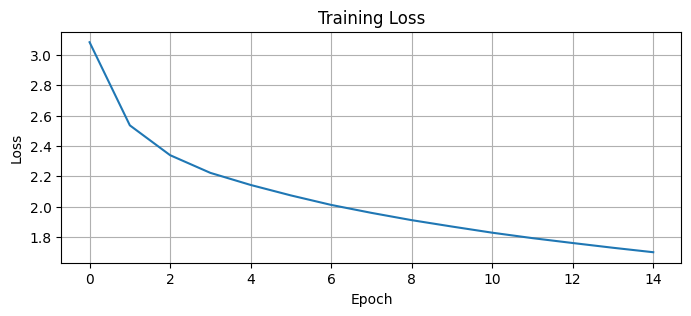

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(history.history["loss"])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [9]:
def sample(probs, temperature=0.8):
    probs = np.log(probs + 1e-8) / temperature
    probs = np.exp(probs)
    probs = probs / np.sum(probs)
    return np.random.choice(len(probs), p=probs)

In [10]:
def generate_poem(seed, length=500, temperature=0.8):
    seed = "".join(c for c in seed if c in char2idx)
    context = (text[:SEQ_LEN] + seed)[-SEQ_LEN:]   # last 100 chars = running context
    result = seed

    for _ in range(length):
        x = np.array([[char2idx[c] for c in context]])
        probs = model.predict(x, verbose=0)[0]
        next_char = idx2char[sample(probs, temperature)]
        result += next_char
        context = context[1:] + next_char

    return result

In [11]:
print(generate_poem("Shall I compare thee to a summer's day\n", length=500, temperature=0.8))

Shall I compare thee to a summer's day
And but pricech the love tormor, and lost,
And thou be joustsor moth lise hear
of duve frie’d hast in love not not docect me.

XXXXXV

Look in your I ich you resten rean’s for thenien stave
To were you brofaged raght in allilled frace,
Whe pair whe fad in for cinderberg to line live so beans and donk,
    The hurth datter to thee porter he brease do love, be and to defurd of the
Fould revort, and love are be iglading and dissrong, atel
    Pruse of thou, in bare and duse, in long stall.


XX

Th


In [12]:
# try your own seed / temperature (0.5 = safe, 1.0 = creative)
print(generate_poem("My love is like\n", length=500, temperature=0.6))

My love is like
Nor the use that ill my bort that for they.

LXXVII


What is but on thou this hore provow. that is more conterbert and me contersing the dow
    And thea this ever dost thee as host bestain dime,
Than thou deart, hath my and to thou and sporadive a deart,
For hant the prove wo from dust then of those thee for sprave thou,
For floop for the will that with extrifate to strond,
    Then thee shall porth and the death all and dessing is parte.
                                                      l


In [13]:
model.save("poem_model.keras")